# CIR and CME Detection from Phase Scintillation

This notebook applies a physically motivated detection pipeline to identify:

- Co-rotating Interaction Regions (CIRs)
- Transient CME-like disturbances

from DSN phase scintillation measurements.

---

## Overview of Method

The detection proceeds in three stages:

### 1. Remove elongation dependence

Phase scintillation strongly depends on solar elongation.  
We model the quiet baseline as a function of elongation and compute:

phase_ratio = observed / expected

This normalises the signal such that:

- quiet conditions → ~1
- disturbed conditions → >1

---

### 2. Detect CIR structures

CIRs are large-scale, long-duration structures.

We:
- smooth the phase_ratio over 12 hours
- apply hysteresis thresholds
- require duration > 24 hours

This isolates sustained enhancements in the solar wind.

---

### 3. Detect transient (CME-like) events

To isolate short-lived events:

- divide by CIR background:
  
  clean_signal = phase_ratio / phase_smooth

- apply a threshold to detect spikes
- filter by duration (0.25–24 hours)

These represent candidate CME-related disturbances.

---

## Output

This notebook produces:

- `phase_windows_detected_<year>.csv`
- `cir_regions_<year>.csv`
- `transient_events_<year>.csv`

---

## Interpretation

The pipeline separates contributions from:

- solar geometry (elongation)
- large-scale solar wind structure (CIRs)
- transient disturbances (CMEs)

This enables DSN Doppler data to be used as a diagnostic of heliospheric activity.

In [6]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.io_utils import load_horizons_daily_sep
from src.detection_utils import (
    BaselineConfig,
    CIRConfig,
    TransientConfig,
    attach_daily_elongation_to_windows,
    build_phase_baseline_vs_elongation,
    detect_cir_regions,
    detect_transient_events,
)
from src.plot_utils import (
    plot_baseline_diagnostics,
    plot_cir_detection,
    plot_transient_detection,
    plot_pipeline_multi_panel,
)

from config.settings_2014 import *   # change year here
sav_file = True
debug = False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"

windows_df = pd.read_csv(
    phase_csv,
    parse_dates=["start", "end", "mid"]
)

horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)
windows_df = attach_daily_elongation_to_windows(windows_df, horizons_daily)
if debug:
    print("Loaded:", phase_csv)
    print("Rows:", len(windows_df))
    print("Missing elongation:", windows_df["elongation_deg"].isna().sum())

windows_df, binned = build_phase_baseline_vs_elongation(windows_df)
if debug:
    print("phase_ratio NaNs:", windows_df["phase_ratio"].isna().sum())

windows_df, cir_df = detect_cir_regions(windows_df)
if debug:
    print("Detected CIR regions:", len(cir_df))
    display(cir_df.head())

In [8]:
transient_cfg = TransientConfig(step_min=20)   # IMPORTANT

windows_df, events_df = detect_transient_events(
    windows_df,
    config=transient_cfg,
)
if debug:
    print("Detected transient events:", len(events_df))
    display(events_df.head())

In [9]:
if sav_file:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    windows_out = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
    cir_out = OUTPUT_DIR / f"cir_regions_{YEAR}.csv"
    events_out = OUTPUT_DIR / f"transient_events_{YEAR}.csv"

    windows_df.to_csv(windows_out, index=False)
    cir_df.to_csv(cir_out, index=False)
    events_df.to_csv(events_out, index=False)

    print("Saved:", windows_out)
    print("Saved:", cir_out)
    print("Saved:", events_out)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_detected_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/cir_regions_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/transient_events_2014.csv


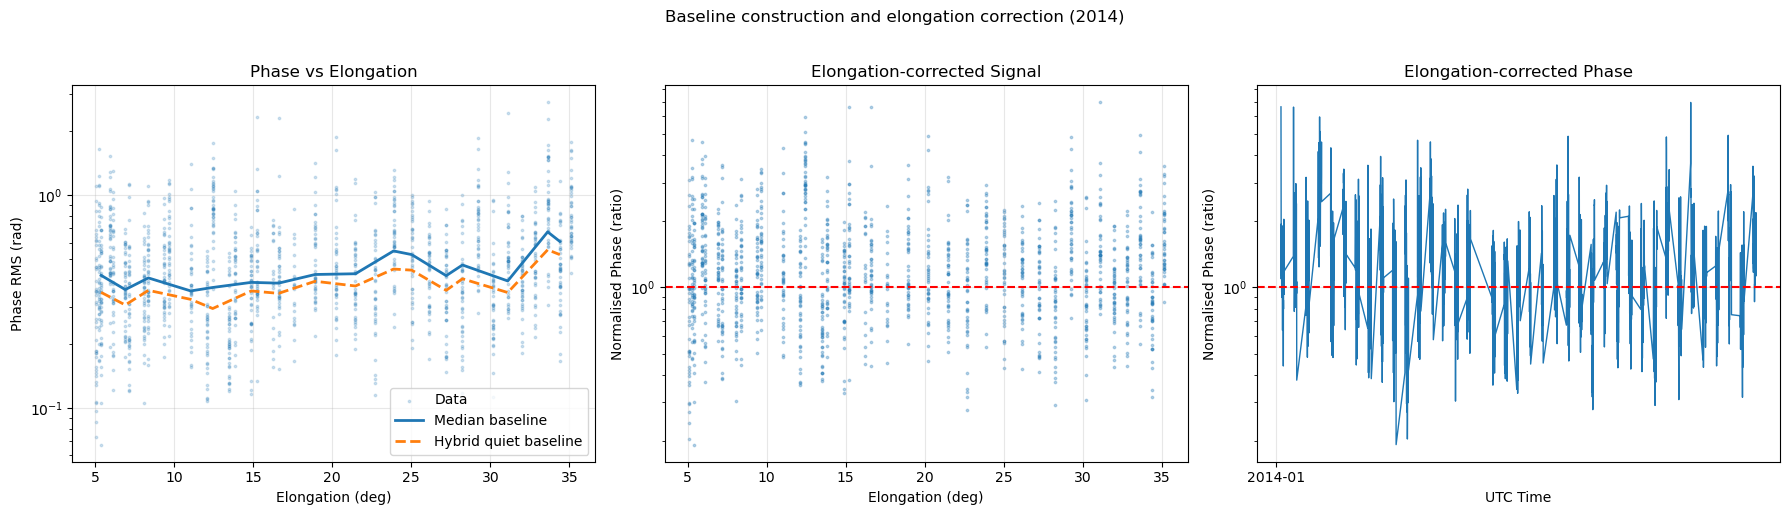

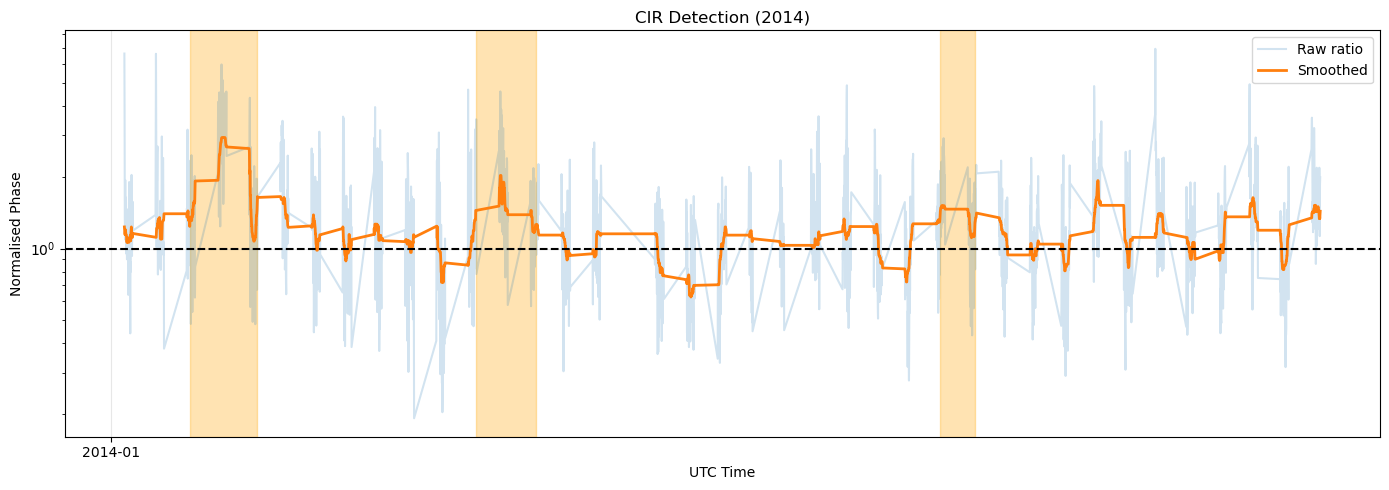

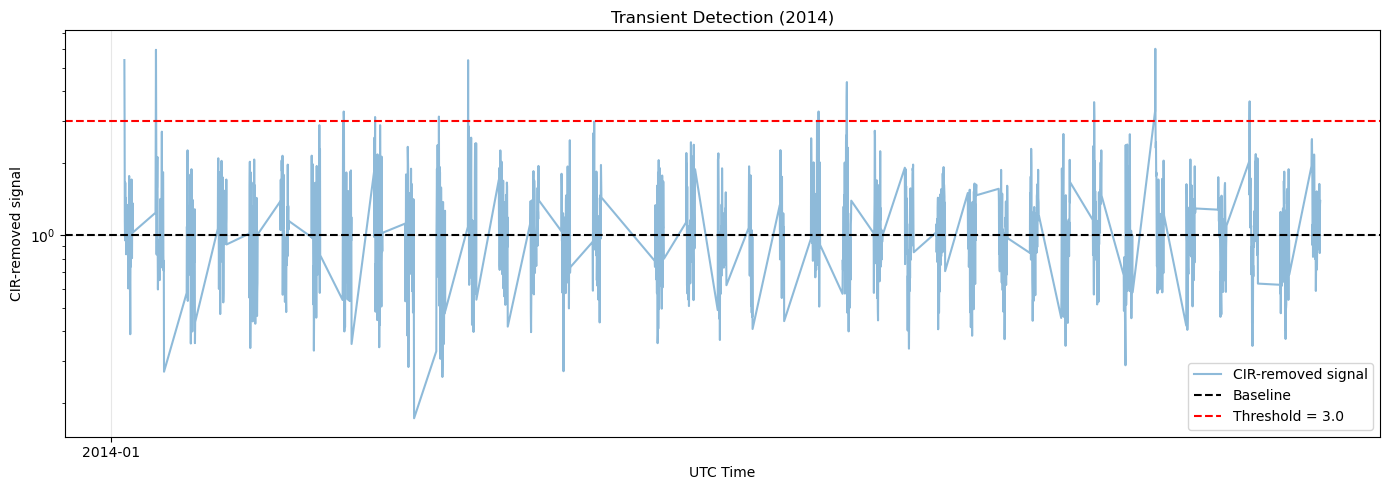

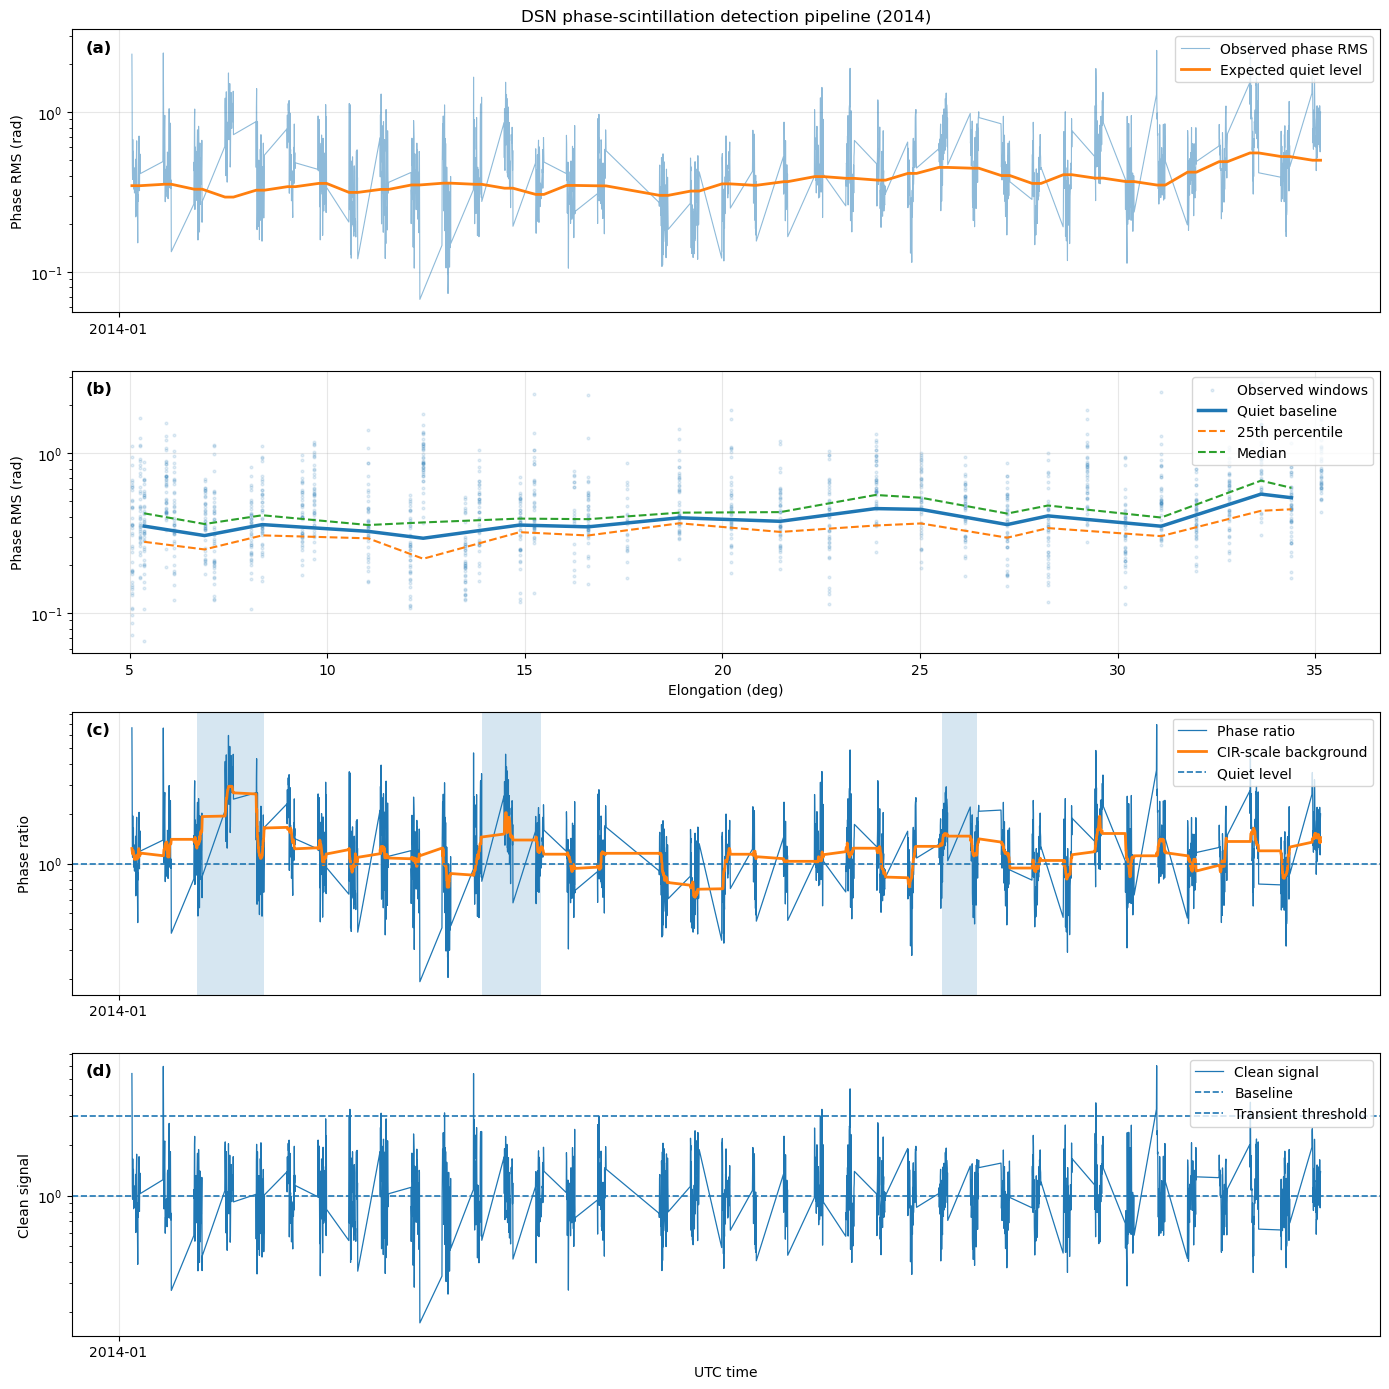

In [10]:
fig, axes = plot_baseline_diagnostics(
    w=windows_df.dropna(subset=["phase_ratio"]).copy(),
    binned=binned,
    year=YEAR,
)
plt.show()

fig, ax = plot_cir_detection(
    w=windows_df.dropna(subset=["phase_ratio", "phase_smooth"]).copy(),
    cir_df=cir_df,
    year=YEAR,
)
plt.show()

fig, ax = plot_transient_detection(
    w=windows_df.dropna(subset=["clean_signal"]).copy(),
    events_df=events_df,
    year=YEAR,
    threshold=3.0,
)
plt.show()

fig, axes = plot_pipeline_multi_panel(
    windows_df=windows_df,
    binned=binned,
    cir_df=cir_df,
    events_df=events_df,
    year=YEAR,
    transient_threshold=3.0,
)
plt.show()